#Mobile Price

1. Explore the Dataset:

In [28]:
import pandas as pd

url ="https://raw.githubusercontent.com/Srinithi-python/LinearRegressionAssignment6/refs/heads/main/mobile_price.csv"
df = pd.read_csv(url)

print("HEAD ::::")
print(f'')
print(df.head())
print(f'')
print("TAIL::::")
print(f'')
print(df.tail())
print(f'')
print("SHAPE::::")
print(df.shape)
print(f'')
print(" COLUMNS::::")
print(f'')
print(df.columns)
print(f'')
print(" INFO")
print(f'')
print(df.info())
print(f'')
print("DATA TYPES")
print(f'')
print(df.dtypes)
print(f'')
print(df.isnull().sum())

HEAD ::::

   Product_id  Price  Sale  weight  resoloution  ppi  cpu core  cpu freq  \
0         203   2357    10   135.0          5.2  424         8      1.35   
1         880   1749    10   125.0          4.0  233         2      1.30   
2          40   1916    10   110.0          4.7  312         4      1.20   
3          99   1315    11   118.5          4.0  233         2      1.30   
4         880   1749    11   125.0          4.0  233         2      1.30   

   internal mem    ram  RearCam  Front_Cam  battery  thickness  
0          16.0  3.000    13.00        8.0     2610        7.4  
1           4.0  1.000     3.15        0.0     1700        9.9  
2           8.0  1.500    13.00        5.0     2000        7.6  
3           4.0  0.512     3.15        0.0     1400       11.0  
4           4.0  1.000     3.15        0.0     1700        9.9  

TAIL::::

     Product_id  Price  Sale  weight  resoloution  ppi  cpu core  cpu freq  \
156        1206   3551  4638   178.0         5.46  53

In [ ]:
print(df.isnull().sum())

Product_id      0
Price           0
Sale            0
weight          0
resoloution     0
ppi             0
cpu core        0
cpu freq        0
internal mem    0
ram             0
RearCam         0
Front_Cam       0
battery         0
thickness       0
dtype: int64


#Create a correlation heatmap focusing on Price

Generate statistical summaries for numerical features

        Product_id        Price         Sale      weight  resoloution  \
count   161.000000   161.000000   161.000000  161.000000   161.000000   
mean    675.559006  2215.596273   621.465839  170.426087     5.209938   
std     410.851583   768.187171  1546.618517   92.888612     1.509953   
min      10.000000   614.000000    10.000000   66.000000     1.400000   
25%     237.000000  1734.000000    37.000000  134.100000     4.800000   
50%     774.000000  2258.000000   106.000000  153.000000     5.150000   
75%    1026.000000  2744.000000   382.000000  170.000000     5.500000   
max    1339.000000  4361.000000  9807.000000  753.000000    12.200000   

              ppi    cpu core    cpu freq  internal mem         ram  \
count  161.000000  161.000000  161.000000    161.000000  161.000000   
mean   335.055901    4.857143    1.502832     24.501714    2.204994   
std    134.826659    2.444016    0.599783     28.804773    1.609831   
min

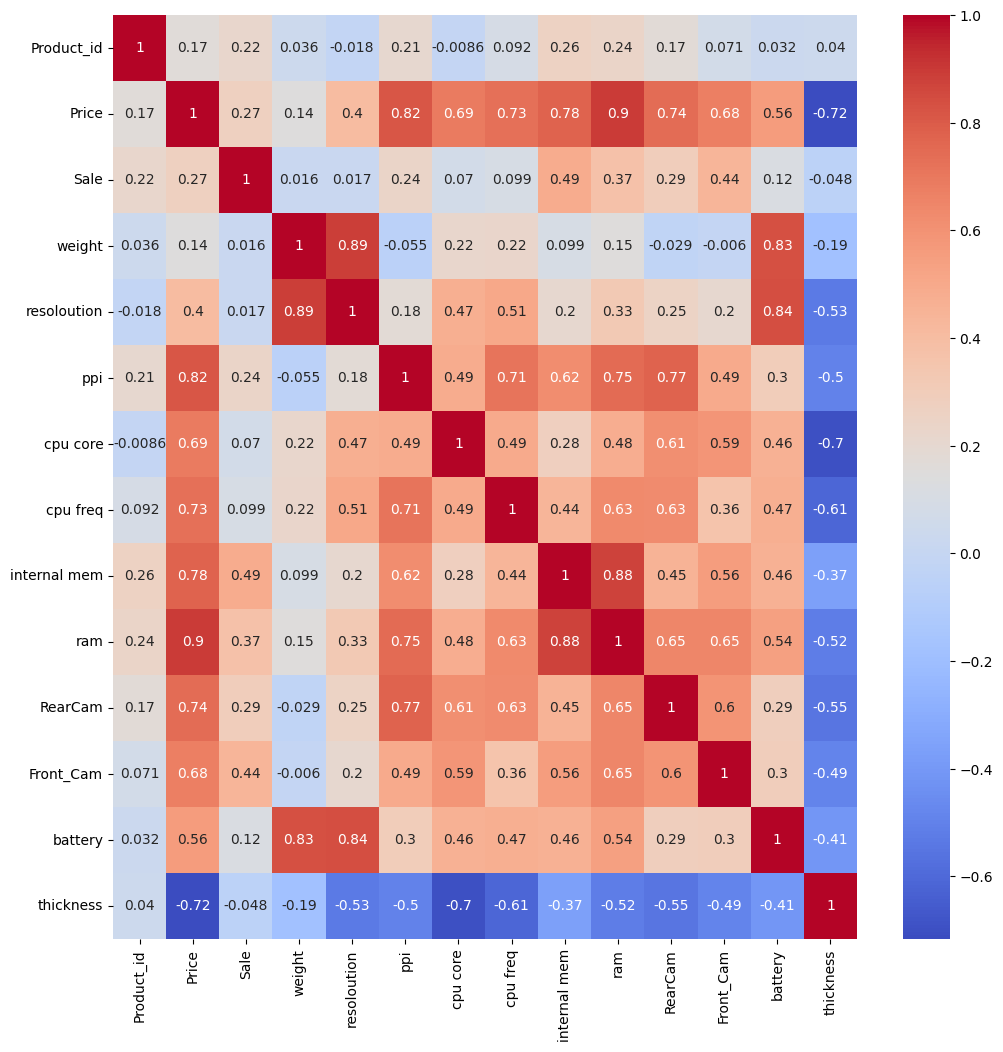

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


url ="https://raw.githubusercontent.com/Srinithi-python/LinearRegressionAssignment6/refs/heads/main/mobile_price.csv"
df = pd.read_csv(url)

df.isna().sum()

numeric_columns=df.select_dtypes(include="number").columns
print(f"Generate statistical summaries for numerical features")
print(f'')
print(df[numeric_columns].describe())

numeric_columns_drop = df.drop("Product_id", axis=1)

corr=df.corr()
plt.figure(figsize=(12,12))
sns.heatmap(corr,cmap="coolwarm",annot=True)
plt.show()

#Identify the top 4 features most correlated with Price

In [30]:
price_correlation = numeric_columns_drop.corr()["Price"].drop("Price")
print(f'Correlation price details ::::::')
print(f'')
print(price_correlation)
print(f'')
top_4 = price_correlation.abs().sort_values(ascending=False).head(4)
print(f'Top 4 Features most correlated with price ::::::')
print(f'')
print(top_4)

Correlation price details ::::::

Sale            0.273263
weight          0.144555
resoloution     0.404010
ppi             0.817614
cpu core        0.686811
cpu freq        0.727383
internal mem    0.776738
ram             0.896915
RearCam         0.739538
Front_Cam       0.675286
battery         0.559946
thickness      -0.716773
Name: Price, dtype: float64

Top 4 Features most correlated with price ::::::

ram             0.896915
ppi             0.817614
internal mem    0.776738
RearCam         0.739538
Name: Price, dtype: float64


#Plot scatter plots for these features against Price and analyze the relationships

In [31]:
top_4_features = price_correlation.loc[top_4.index]

print("Top 4 features and their correlation with Price:")
print(top_4_features)


Top 4 features and their correlation with Price:
ram             0.896915
ppi             0.817614
internal mem    0.776738
RearCam         0.739538
Name: Price, dtype: float64


In [ ]:
top_4_features = price_correlation.loc[top_4.index]

print("Top 4 features and their correlation with Price:")
print(top_4_features)


Top 4 features and their correlation with Price:
ram             0.896915
ppi             0.817614
internal mem    0.776738
RearCam         0.739538
Name: Price, dtype: float64


**RAM,PPI, internal memory , Rear Camera are the top features correlated with price in the above listed data set.**

Plot scatter plots for these features against Price and analyze the relationships

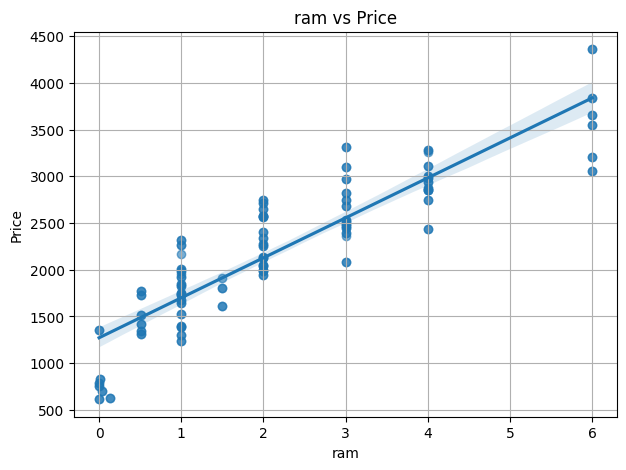

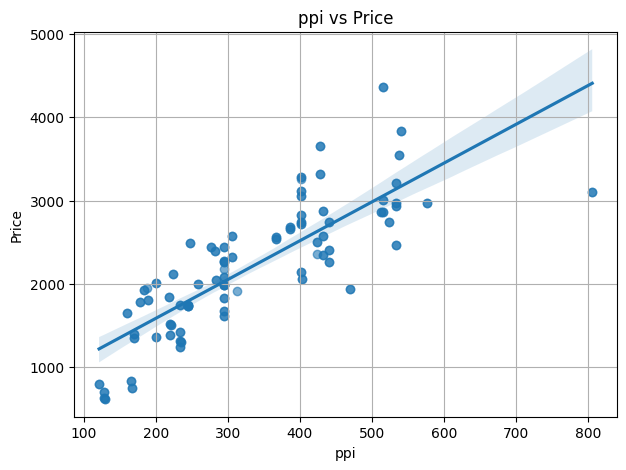

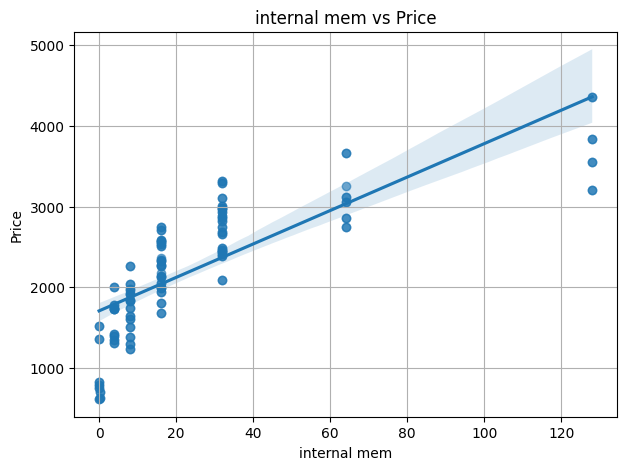

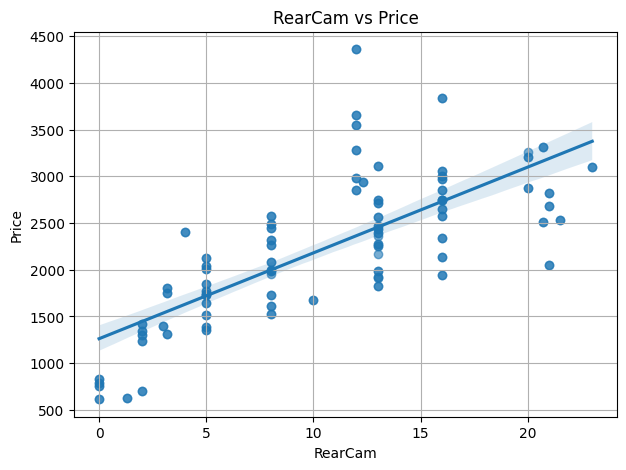

In [ ]:
price_correlation_Features = df[["ram", "ppi", "internal mem","RearCam"]].head(5)
price_correlation_Features

features = ["ram", "ppi", "internal mem","RearCam"]

for feature in features:
    plt.figure(figsize=(7, 5))

    sns.regplot(
        data=df,
        x=feature,
        y="Price",
        scatter_kws={"alpha": 0.6},
        line_kws={}
    )

    plt.title(f"{feature} vs Price")
    plt.xlabel(feature)
    plt.ylabel("Price")
    plt.grid(True)
    plt.show()

Analysis

1. RAM vs Price

Shows a strong positive relationship.
As RAM increases, mobile Price generally increases.
Correlation is approximately 0.90, making RAM the strongest of these features.

2. PPI vs Price

Shows a strong positive relationship.
Higher PPI generally corresponds to higher-priced phones.
Correlation is approximately 0.82.

3. Internal Memory vs Price

Shows a strong positive relationship.
Phones with greater internal storage tend to have higher prices.
Correlation is approximately 0.78.

4. Rear Camera vs Price

Shows a positive relationship.
Higher rear-camera specifications tend to be associated with higher prices.
Correlation is approximately 0.74.
Overall insight

The scatter plots generally show upward trends between these four features and Price. RAM, PPI, Internal Memory, and Rear Camera are all positively associated with mobile phone price, with RAM showing the strongest linear association among them. Correlation describes association and does not by itself establish causation.

#2. Prepare the Data:


2.1. Feature Selection: Select the features and the target variable for your analysis.

In [ ]:


features = ["ram", "ppi", "internal mem","RearCam"]

X = df[features]
y = df["Price"]

print("Selected Features:")
print(X.head())

print("\nTarget Variable:")
print(y.head())

Selected Features:
     ram  ppi  internal mem  RearCam
0  3.000  424          16.0    13.00
1  1.000  233           4.0     3.15
2  1.500  312           8.0    13.00
3  0.512  233           4.0     3.15
4  1.000  233           4.0     3.15

Target Variable:
0    2357
1    1749
2    1916
3    1315
4    1749
Name: Price, dtype: int64



2.2. Split the Dataset: Divide the dataset into training and testing sets. Use 80% of the data for
training and 20% for testing.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

features = ["ram", "ppi", "internal mem","RearCam"]
X = df[features]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features::::::", X_train.shape)
print("Testing features::::::", X_test.shape)
print("Training target::::", y_train.shape)
print("Testing target:::::", y_test.shape)

Training features:::::: (128, 4)
Testing features:::::: (33, 4)
Training target:::: (128,)
Testing target::::: (33,)


3. Build and Train the Model:


3.1. Create a Linear Regression Model: Build a linear regression model using the training data.
3.2. Train the Model: Fit the model to the training data.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

features = ["ram", "ppi", "internal mem","RearCam"]
X = df[features]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


#4. Evaluate the Model:


4.1. Predict: Use the model to make predictions on the test set.
4.2. Metrics Calculation: Evaluate the model’s performance using the following metrics:
❖ Slope (Coefficient) and Intercept: Print the slope (coefficient) and intercept of the
regression line.
❖ Model Performance Metrics: Calculate and report the following metrics:
❖ R2 Score: How well does the model explain the variance in the target variable?
❖ Mean Absolute Error (MAE): What is the average absolute difference between predicted
and actual values?
❖ Mean Squared Error (MSE): What is the average of the squared differences between
predicted and actual values?

In [ ]:

y_pred = model.predict(X_test)

print("Predicted Prices:")
print(y_pred)

Predicted Prices:
[1151.82776887 1813.89036794 2761.61894285 1409.55626241 1472.37478409
 1618.73662759 1151.82776887 1338.41102317 2403.63970656 2761.61894285
 1563.85244648 1520.80558755 1907.31589118 2877.37749897 2455.80152917
 2356.46071015 2267.44316458 3488.17615311 1660.86328398 2356.46071015
 2149.22319868 1907.31589118 1873.75737526 2403.63970656 3087.95873099
 3604.2366836  2252.13706492 3446.41750941 2771.82808012 2414.91793847
 2877.37749897 2300.06955056 2743.97282734]


In [ ]:

print("Intercept:::::", model.intercept_)
print("Coefficients (Slopes):::::")

for feature, coefficient in zip(features, model.coef_):
    print(f"{feature}: {coefficient:.4f}")

Intercept: 915.6007300109341

Coefficients (Slopes):
ram: 275.4658
ppi: 1.4098
internal mem: 0.5495
RearCam: 19.9557


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Model Performance Metrics")
print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.2f}")
print(f"MSE      : {mse:.2f}")
print(f"RMSE     : {rmse:.2f}")

Model Performance Metrics
R² Score : 0.8528
MAE      : 246.33
MSE      : 83466.34
RMSE     : 288.91


Insights
You can write the following in your assignment:

The R² score indicates how well the selected features — RAM, PPI, Internal Memory, and Rear Camera — explain variations in mobile Price.
A higher R² value indicates that the Linear Regression model provides a better fit to the test data.
MAE represents the average absolute difference between the actual and predicted mobile prices. A lower MAE indicates more accurate predictions.
MSE gives greater importance to larger prediction errors because the errors are squared. A lower MSE indicates better model performance.
RMSE represents the typical prediction error in the same units as Price. A lower RMSE indicates that predictions are closer to the actual prices.
Overall, these metrics help assess how accurately the Linear Regression model predicts mobile prices on unseen test data.

The Linear Regression model uses RAM, PPI, Internal Memory, and Rear Camera to predict mobile prices. Model performance is evaluated using R², MAE, MSE, and RMSE, where a higher R² and lower error values indicate better predictive performance.

**❖ R2 Score: How well does the model explain the variance in the target variable?**


The R² score indicates the proportion of variation in mobile Price that can be explained by the selected features—RAM, PPI, Internal Memory, and Rear Camera. A higher R² score indicates that the model explains a greater proportion of the variation in mobile prices.

❖<b> Mean Absolute Error (MAE): What is the average absolute difference between predicted
and actual values? </b>



The Mean Absolute Error represents the average absolute difference between the actual and predicted mobile prices. A lower MAE indicates better prediction accuracy. For example, an MAE of ₹2,500 means that the model's predicted prices are off from the actual prices by approximately ₹2,500 on average.

<b>❖ Mean Squared Error (MSE): What is the average of the squared differences between
predicted and actual values?</b>


The Mean Squared Error measures the average squared difference between actual and predicted mobile prices. Since the errors are squared, larger errors have a greater impact on the MSE. A lower MSE indicates better model performance.

#5. Conclude the Analysis:


5.1. Model Evaluation: Based on the performance metrics, assess how well the model predicts
mobile prices. Discuss whether the model’s performance is satisfactory or if there are areas
for improvement.
5.2. Insights and Discussion:
❖ What insights did you gain from the correlation analysis and scatter plots?
❖ How do the selected features contribute to the prediction of mobile prices?
❖ What do the slope (coefficient) and intercept reveal about the relationship between the
features and the target variable?
❖ How well does the model perform based on the evaluation metrics? Are there any
discrepancies between the predicted and actual values?
❖ What might be some potential improvements or additional steps you could take to
enhance the model’s performance?



The Linear Regression model provides a way to predict mobile prices using RAM, PPI, Internal Memory, and Rear Camera. The model's performance should be assessed using R², MAE, MSE, and RMSE on the test dataset. A higher R² score combined with lower MAE and RMSE indicates that the model predicts prices more accurately.

If the R² score is relatively high and the error values are reasonably low compared with the range of mobile prices, the model can be considered satisfactory for this analysis. However, there may still be scope for improvement. Additional relevant features such as battery capacity, processor specifications, display characteristics, storage, and camera specifications could be considered. Other regression algorithms and feature engineering could also be tested to determine whether prediction accuracy improves.

